In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Ejercicio 11 - Trayectorias parabólicas con resistencia aerodinámica.

Casi todos los problemas en física que analizan trayectorias en el aire desprecian el rozamiento que produce, para conseguir soluciones analíticas.  
Vamos a estudiar que ocurre cuando se tiene en cuenta en el movimiento parabólico. 

Sea un proyectil esférico lanzado desde el suelo. La resistencia a una esfera producida por el aire es una fuerza en sentido contrario al movimiento cuyo módulo viene dado por

$$\vert F\vert=\frac{1}{2}\pi R^2\rho Cv^2,$$

donde $R$ es el radio de la esfera, $\rho$ en la densidad del aire, $v$ la velocidad del proyectil, y $C$ es el llamado coeficiente de arrastre, que depende de la forma del objeto.

1. Empezando por las ecuaciones de Newton mostrar que las ecuaciones de movimiento del proyectil en el pano son

    $$\ddot x=-\frac{\pi R^2\rho C}{2m}\dot x\sqrt{\dot x^2+\dot y^2},\quad \ddot y=-g-\frac{\pi R^2\rho C}{2m}\dot y\sqrt{\dot x^2+\dot y^2},$$

    siendo $m$ la masa del proyectil y $g$ la aceleración de la gravedad. 


2. Obtener la solución de las ecuaciones de movimiento para un proyectil de masa 1 Kg, $R=8$ cm, disparado con un ángulo de $30^\circ$ con respecto a la horizontal y con una velocidad inicial de 100 $m\cdot s^{-1}$, teniendo en cuenta que la densidad del aire es de 1.22 kg m$^{-3}$ y el coeficiente de arrastre para una esfera es C=0.47. Representar la trayectoria en el plano xy.


3. Cuando uno desprecia el rozamiento la distancia alcanzado por el proyectil es independiente de su masa. 
   En la vida real, sin embargo, eso no es así. Usar el programa para determinar cual es la dependencia de la distancia horizontal recorrida por el proyectil en función de su masa. 

---

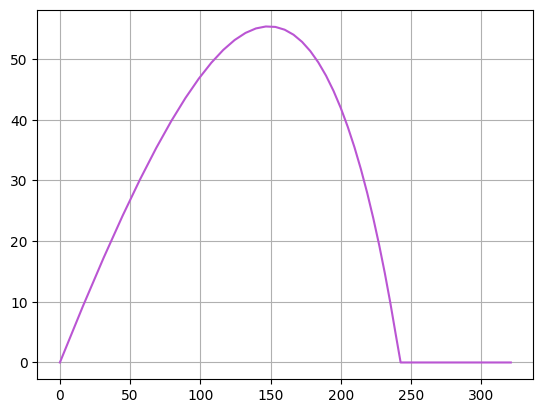

In [ ]:
m, R, theta, v0, rho, C, g = 1, 0.08, 30 * np.pi / 180, 100, 1.22, 0.47, 9.81
a = np.pi * (R**2) * rho * C / (2 * m)

x0 = y0 = 0
vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)
r = np.array([x0, y0, vx0, vy0], float)

def F(r, t):
    x, y, vx, vy = r

    fx = vx
    fy = vy
    fvx = -a * vx * np.sqrt(vx**2 + vy**2)
    fvy = -a * vy * np.sqrt(vx**2 + vy**2) - g
    return np.array([fx, fy, fvx, fvy], float)

def trajectories(F, a, b, N, r):
    h = (b - a) / N
    time = np.linspace(a, b, N)
    xp, yp = [], []
    r = np.array(r, float)

    for t in time:
        xp.append(r[0])
        yp.append(r[1])

        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return time, xp, yp

t, x, y = trajectories(F, 0, 20, 100, r)
y = [max(yi, 0) for yi in y]

plt.plot(x, y, color=mc)
plt.grid()
plt.show()